# Linear Algebra Applied — Linear Regression to Systems of Equations

*Course notes for **Math for Machine Learning**, C1 · W1 · L1 — "Linear Algebra Applied 1" (DeepLearning.AI).*

This notebook follows the lecture and turns its slides into runnable code. The big idea:

> Many machine-learning models are, at their core, **linear models**. Training one means fitting a line / hyperplane to data, and once we have many data examples this naturally becomes a **system of linear equations** — the object linear algebra is built to handle.

## Learning objectives

1. See *why* linear algebra shows up in machine learning.
2. Model a single-feature problem with linear regression: $y = mx + b$.
3. Extend to many features: $y = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$.
4. Stack many data examples and recognize a **system of linear equations**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Why linear algebra for machine learning?

In **supervised machine learning** we learn a function that maps **inputs** to **outputs** from examples.

```
  Input  ─▶  [ model ]  ─▶  Output
```

The simplest, and one of the most widely used, supervised models is **linear regression**. As we will see, fitting a linear model to data is exactly a linear-algebra problem — which is why linear algebra is foundational for ML.

## 2. A single feature: predicting wind-turbine power

**Goal:** predict a wind turbine's **power output (kW)** from the **wind speed (m/s)**.

- **Input** $x$ — wind speed
- **Output** $y$ — power output

If we plot measured data, the points roughly follow a straight line, so we model the relationship as

$$ y = m\,x + b $$

where $m$ is the slope and $b$ the intercept. Equivalently, in the lecture's words:

$$ m \times \text{wind speed} + b = \text{power output} $$

Once $m$ and $b$ are known, a new wind speed (e.g. 5 m/s) gives a prediction (e.g. ~1500 kW).

In [3]:
# Synthetic data resembling the lecture's scatter plot.
wind_speed = np.array([2.5, 3, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6, 6.5, 7, 7.5, 8, 9])
power      = np.array([100, 150, 300, 500, 900, 1200, 1500, 1700,
                       2100, 1800, 2400, 2600, 2900, 3100, 3500])

# Fit a line y = m*x + b (least squares, degree-1 polynomial).
m, b = np.polyfit(wind_speed, power, deg=1)
print(f"slope     m = {m:.1f} kW per (m/s)")
print(f"intercept b = {b:.1f} kW")

x_pred = 5.0
print(f"\nPrediction at {x_pred} m/s -> {m * x_pred + b:.0f} kW")

slope     m = 559.0 kW per (m/s)
intercept b = -1368.5 kW

Prediction at 5.0 m/s -> 1426 kW


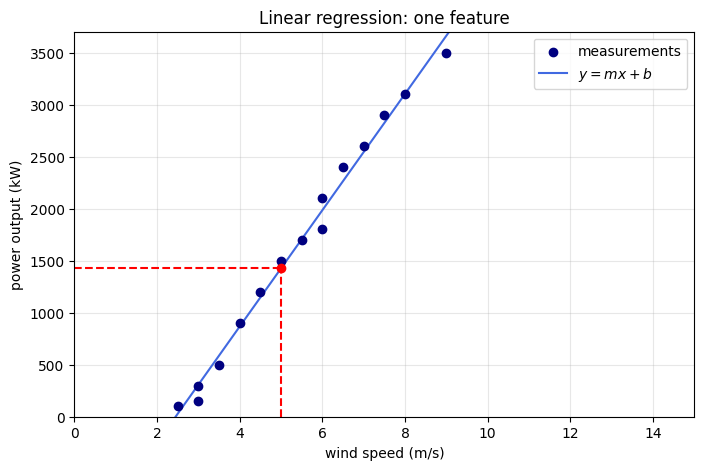

In [3]:
xs = np.linspace(0, 15, 100)
plt.scatter(wind_speed, power, color="navy", zorder=3, label="measurements")
plt.plot(xs, m * xs + b, color="royalblue", label=r"$y = mx + b$")

# Highlight the prediction at 5 m/s.
y5 = m * x_pred + b
plt.plot([x_pred, x_pred], [0, y5], "r--")
plt.plot([0, x_pred], [y5, y5], "r--")
plt.scatter([x_pred], [y5], color="red", zorder=4)

plt.xlim(0, 15); plt.ylim(0, 3700)
plt.xlabel("wind speed (m/s)"); plt.ylabel("power output (kW)")
plt.title("Linear regression: one feature")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. More than one feature

Power output does not depend on wind speed alone — **air temperature** matters too (it affects air density). With two inputs $x_1$ (wind speed) and $x_2$ (temperature) the model becomes

$$ y = w_1 x_1 + w_2 x_2 + b $$

The slope is now split into one **weight** $w_i$ per feature. In general, with $n$ features,

$$ y = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b $$

Each feature contributes $w_i x_i$, and $b$ is the bias term. This is just a dot product plus a bias:

$$ y = \mathbf{w}^\top \mathbf{x} + b. $$

In [4]:
# Two features: [wind speed, temperature].  y = w1*x1 + w2*x2 + b
w = np.array([380.0, -12.0])   # weights
b2 = -700.0                    # bias

x_example = np.array([6.0, 15.0])   # 6 m/s, 15 C
y_example = w @ x_example + b2      # dot product + bias
print(f"features x = {x_example}")
print(f"predicted power = {y_example:.0f} kW")

features x = [ 6. 15.]
predicted power = 1400 kW


## 4. Many data examples → a system of linear equations

So far we wrote *one* equation. But we have **many measured examples**. Writing the model for each example $i = 1, \dots, m$ (superscript $(i)$ indexes the example) gives:

$$
\begin{aligned}
w_1 x_1^{(1)} + w_2 x_2^{(1)} + \dots + w_n x_n^{(1)} + b &= y^{(1)} \\
w_1 x_1^{(2)} + w_2 x_2^{(2)} + \dots + w_n x_n^{(2)} + b &= y^{(2)} \\
&\;\vdots \\
w_1 x_1^{(m)} + w_2 x_2^{(m)} + \dots + w_n x_n^{(m)} + b &= y^{(m)}
\end{aligned}
$$

This is a **system of linear equations**. The unknowns we want to solve for are the weights $w_1, \dots, w_n$ and bias $b$; the $x^{(i)}$ and $y^{(i)}$ come from the data.

Folding the bias into the weights (by appending a constant feature $1$), the whole system is one matrix equation:

$$ X \mathbf{w} = \mathbf{y} $$

Studying *when* such systems have a unique solution, and *how* to solve them efficiently, is exactly what the rest of this course is about.

In [5]:
# A small, exactly-determined example: 3 unknowns (w1, w2, b), 3 examples.
# Each row is one data example [wind_speed, temperature, 1].
X = np.array([
    [5.0, 10.0, 1.0],
    [6.0, 15.0, 1.0],
    [8.0, 20.0, 1.0],
])
y = np.array([1500.0, 1980.0, 2860.0])

# Solve the system X @ [w1, w2, b] = y
solution = np.linalg.solve(X, y)
w1, w2, bias = solution
print(f"w1 (wind)        = {w1:.2f}")
print(f"w2 (temperature) = {w2:.2f}")
print(f"b  (bias)        = {bias:.2f}")

# Check the solution reproduces the outputs.
print("\nX @ solution =", X @ solution)
print("y            =", y)

w1 (wind)        = 400.00
w2 (temperature) = 16.00
b  (bias)        = -660.00

X @ solution = [1500. 1980. 2860.]
y            = [1500. 1980. 2860.]


## 5. Summary

| Step | Model | Linear-algebra view |
|------|-------|--------------------|
| One feature | $y = mx + b$ | a line |
| $n$ features | $y = w_1x_1 + \dots + w_nx_n + b$ | dot product $\mathbf{w}^\top\mathbf{x} + b$ |
| $m$ examples | one equation per example | system $X\mathbf{w} = \mathbf{y}$ |

**Key takeaway:** training a linear model = solving (or best-fitting) a system of linear equations. That is why linear algebra — vectors, matrices, and systems of equations — is the foundation of machine learning.

**Next up:** how to represent and solve systems of linear equations, when a unique solution exists, and what to do when it doesn't (over- and under-determined systems).